# Lecture 03 · Build the Archer 🏹  — Policy Gradients from scratch

**RL in Production · Vizuara AI Labs**

In the lecture you met the Archer: a one-state **bandit** (nine firing angles), then
an **MDP** where the archer can *walk* before it shoots. In this assignment you
build that exact world in code and climb the **variance ladder** the lecture is
organised around:

> **REINFORCE → REINFORCE + baseline → Actor-Critic**

You will implement each method **from scratch in PyTorch** (no Stable-Baselines3),
watch the nine-angle fan sharpen, teach the archer to walk in before shooting, and
**measure the gradient variance** drop as you add a baseline and then a critic.

**Cells marked ✅ PROVIDED are complete — run them. Cells marked 📝 TODO are yours
to finish** (each is one or two lines, with the equation from the slide right next
to it). Everything downstream calls your code, so fill the TODOs top to bottom.

Runs on a free CPU Colab in a few minutes.

In [1]:
# ✅ PROVIDED — setup
import numpy as np, torch, torch.nn as nn
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
GAMMA = 0.95

## Part 0 · The Archer worlds and the networks (✅ provided)

Two custom `gymnasium` environments — exactly the ones from the slides.

In [2]:
# ✅ PROVIDED — the two Archer environments
class ArcherBandit(gym.Env):
    """One state, 9 firing angles, reward = closeness to the bullseye (centre angle)."""
    N_ANGLES, TARGET, SIGMA = 9, 4, 1.5
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(0., 1., (1,), np.float32)
        self.action_space = spaces.Discrete(self.N_ANGLES)
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed); return np.array([0.], np.float32), {}
    def step(self, a):
        r = float(np.exp(-((a - self.TARGET)**2) / (2*self.SIGMA**2)))
        return np.array([0.], np.float32), r, True, False, {}

class ArcherMDP(gym.Env):
    """State = distance to target. Actions: 0=step closer, 1=step back, 2=shoot.
    Each step costs -0.2; shooting ends the episode with a reward that is higher
    up close (+10 at 10m, -1.2 at 50m). Optimal: walk in, then shoot."""
    CLOSER, BACK, SHOOT = 0, 1, 2
    MIN_D, MAX_D = 10., 50.
    def __init__(self, max_steps=25):
        super().__init__()
        self.observation_space = spaces.Box(0., 1., (1,), np.float32)
        self.action_space = spaces.Discrete(3); self.max_steps = max_steps
    def _obs(self): return np.array([self.d / self.MAX_D], np.float32)
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.d = float(self.np_random.choice([10.,20.,30.,40.,50.])); self.t = 0
        return self._obs(), {}
    def shoot_reward(self, d): return 10. - 0.28*(d - self.MIN_D)
    def step(self, a):
        self.t += 1
        if a == self.SHOOT:
            return self._obs(), float(self.shoot_reward(self.d)), True, False, {}
        self.d = float(np.clip(self.d + (-10. if a == self.CLOSER else 10.), self.MIN_D, self.MAX_D))
        return self._obs(), -0.2, False, self.t >= self.max_steps, {}

In [3]:
# ✅ PROVIDED — the policy network (outputs action logits) and value network V(s)
class Policy(nn.Module):
    def __init__(self, obs_dim, n_act, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, h), nn.Tanh(), nn.Linear(h, n_act))
    def forward(self, x): return self.net(x)              # logits

class Value(nn.Module):
    def __init__(self, obs_dim, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, h), nn.Tanh(), nn.Linear(h, 1))
    def forward(self, x): return self.net(x).squeeze(-1)  # scalar V(s)

### 📝 TODO 1 — sample an action and get its log-probability

The policy outputs **logits**; turn them into a distribution, **sample** an action,
and return both its **log-probability** and the distribution's **entropy** (we add a
small entropy bonus to keep exploring). This is the `∇log π` machinery from §4.3.

In [4]:
# 📝 TODO 1 — complete the three marked lines
def act(policy, state_np):
    st = torch.tensor(state_np, dtype=torch.float32)
    logits = policy(st)
    dist = torch.distributions.Categorical(logits=logits)   # ✅ provided
    action  = dist.sample()   # Sample an action based on policy
    logp    = dist.log_prob(action)  # log_prob of that action
    entropy = dist.entropy()   # get entropy of the distribution
    return action, logp, entropy

In [5]:
# ✅ PROVIDED — roll out one full episode using your act()
def run_episode(env, policy):
    s, _ = env.reset(); S, A, logps, ents, R = [], [], [], [], []
    done = False
    while not done:
        a, logp, ent = act(policy, s)
        s2, r, term, trunc, _ = env.step(int(a))
        S.append(s); A.append(int(a)); logps.append(logp); ents.append(ent); R.append(r)
        s = s2; done = term or trunc
    return S, A, logps, ents, R

## Part A · The bandit + REINFORCE

One state, nine angles. There is no future, so the weight on the sampled angle is
simply its **reward** (the §3 bandit). Watch the fan sharpen onto the bullseye.

### 📝 TODO 2 — the REINFORCE update (bandit)

The estimator is $\hat g = r\,\nabla\log\pi(a)$. As a loss to *minimise* (optimizers
descend), that is `loss = -(reward * logp)`. Add the small entropy bonus.

In [6]:
# 📝 TODO 2 — complete the loss line
def train_bandit(episodes=1500, lr=0.01, ent_coef=0.1):
    env = ArcherBandit(); pol = Policy(1, env.N_ANGLES)
    opt = torch.optim.Adam(pol.parameters(), lr); hist = []
    for ep in range(episodes):
        _, _, logps, ents, R = run_episode(env, pol)
        logp, ent, r = logps[0], ents[0], R[0]
        loss = -(r * logp) - ent_coef * ent   # REINFORCE loss for one shot, with entropy bonus
                     #          hint:  -(r * logp) - ent_coef * ent
        opt.zero_grad(); loss.backward(); opt.step(); hist.append(r)
    return pol, hist

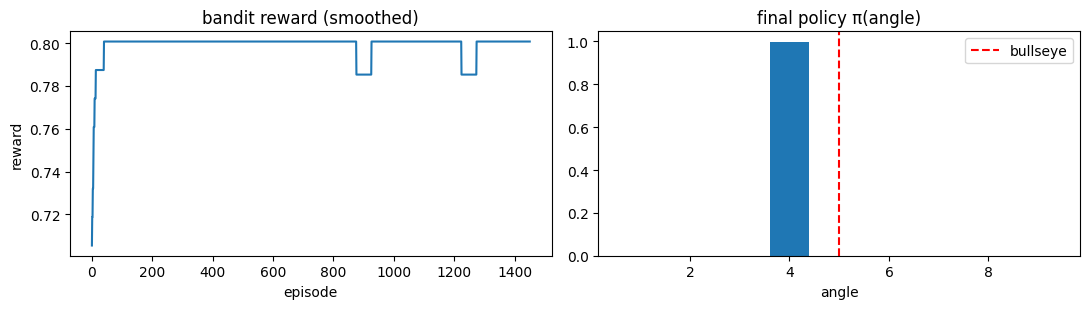

mean reward (last 200): 0.801  (uniform ≈ 0.42)


In [7]:
# ✅ PROVIDED — train and watch the nine-angle fan sharpen
pol_b, hist_b = train_bandit()
probs = torch.softmax(pol_b(torch.zeros(1)), -1).detach().numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(np.convolve(hist_b, np.ones(50)/50, 'valid')); ax[0].set_title('bandit reward (smoothed)')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('reward')
ax[1].bar(range(1, 10), probs); ax[1].set_title('final policy π(angle)')
ax[1].set_xlabel('angle'); ax[1].axvline(ArcherBandit.TARGET+1, ls='--', c='r', label='bullseye')
ax[1].legend(); plt.tight_layout(); plt.show()
print('mean reward (last 200):', round(np.mean(hist_b[-200:]), 3), ' (uniform ≈ 0.42)')

## Part B · The MDP — REINFORCE → +baseline → Actor-Critic

Now the archer can walk. An action changes the next state, so a single reward
becomes the **return** $G_t$, and we climb the variance ladder.

### 📝 TODO 3 — discounted returns

$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots$  (compute it backwards).

In [8]:
# 📝 TODO 3 — complete the accumulation line
def discounted_returns(rewards, gamma=GAMMA):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G                # One step of the recursion for return   (hint: r + gamma * G)
        out.append(G)
    return list(reversed(out))

### 📝 TODO 4 & 5 — REINFORCE, and REINFORCE **+ baseline**

Vanilla REINFORCE weights each step by its return $G_t$. The **baseline** version
subtracts a learned value $V(s_t)$ so the weight becomes the **advantage**
$A_t = G_t - V(s_t)$ — same gradient in expectation, far less noise (§7). The
critic $V$ is trained by regressing onto the returns it saw.

In [9]:
# 📝 TODO 4 & 5 — complete the advantage (and, if baseline, the critic loss)
def reinforce(env, episodes=1500, lr=0.01, baseline=False, ent_coef=0.01):
    pol = Policy(1, env.action_space.n); popt = torch.optim.Adam(pol.parameters(), lr)
    val = Value(1) if baseline else None
    vopt = torch.optim.Adam(val.parameters(), lr) if baseline else None
    curve = []
    for ep in range(episodes):
        S, A, logps, ents, R = run_episode(env, pol)
        states = torch.tensor(np.array(S), dtype=torch.float32)
        G = torch.tensor(discounted_returns(R), dtype=torch.float32)
        if baseline:
            v = val(states)
            critic_loss = ((G - v)**2).mean()    # MSE of V(s) onto the returns G   (hint: ((G - v)**2).mean())
            vopt.zero_grad(); critic_loss.backward(); vopt.step()
            adv = G - val(states).detach()            # 📝 TODO 5: advantage = return - baseline    (hint: G - val(states).detach())
        else:
            adv = G           # 📝 Vanilla REINFORCE weight         (hint: just G)
        logp = torch.stack(logps); ent = torch.stack(ents)
        loss = -(adv * logp).mean() - ent_coef * ent.mean()   # ✅ provided (the §4.3 update)
        popt.zero_grad(); loss.backward(); popt.step()
        curve.append(sum(R))
    return pol, val, curve

### 📝 TODO 6 — Actor-Critic (the TD advantage)

Instead of the full Monte-Carlo return, the critic bootstraps: the advantage is the
**TD error** $\delta = r + \gamma V(s') - V(s)$ (§8). We use a per-episode batched
update with a short **critic warm-up** (let $V$ settle before the actor moves) for
stability.

In [11]:
# 📝 TODO 6 — complete the TD target and the advantage
def actor_critic(env, episodes=2000, lr_a=0.004, lr_c=0.03, ent_coef=0.01, warmup=150):
    pol = Policy(1, env.action_space.n); popt = torch.optim.Adam(pol.parameters(), lr_a)
    val = Value(1); vopt = torch.optim.Adam(val.parameters(), lr_c); curve = []
    for ep in range(episodes):
        s, _ = env.reset(); S, logps, ents, R, S2, Dn = [], [], [], [], [], []
        done = False
        while not done:
            a, logp, ent = act(pol, s)
            s2, r, term, trunc, _ = env.step(int(a)); done = term or trunc
            S.append(s); logps.append(logp); ents.append(ent); R.append(r)
            S2.append(s2); Dn.append(float(term)); s = s2
        states = torch.tensor(np.array(S),  dtype=torch.float32)
        snext  = torch.tensor(np.array(S2), dtype=torch.float32)
        rew = torch.tensor(R, dtype=torch.float32); dn = torch.tensor(Dn)
        with torch.no_grad():
            target = rew + GAMMA * val(snext) * (1-dn)   # 1-step TD target (0 at terminal)
                           #            hint:  rew + GAMMA * val(snext) * (1 - dn)
        v = val(states)
        adv = (target - v).detach()         # The TD-error advantage     (hint: (target - v).detach())
        vopt.zero_grad(); (target - v).pow(2).mean().backward(); vopt.step()   # ✅ critic update
        if ep >= warmup:                                                        # ✅ actor update
            logp = torch.stack(logps); ent = torch.stack(ents)
            popt.zero_grad()
            (-(adv * logp).mean() - ent_coef * ent.mean()).backward(); popt.step()
        curve.append(sum(R))
    return pol, val, curve

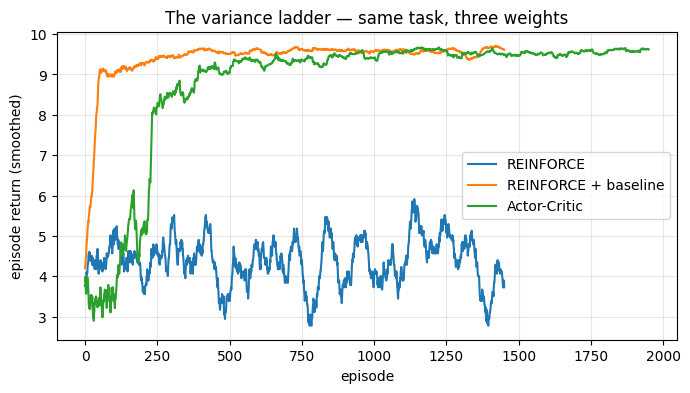

In [12]:
# ✅ PROVIDED — train all three on the MDP and plot the learning curves
def smooth(x, k=50): return np.convolve(x, np.ones(k)/k, 'valid')
pol1, _,    c1 = reinforce(ArcherMDP(), baseline=False)
pol2, val2, c2 = reinforce(ArcherMDP(), baseline=True)
pol3, val3, c3 = actor_critic(ArcherMDP())
plt.figure(figsize=(8, 4))
for c, lbl in [(c1,'REINFORCE'), (c2,'REINFORCE + baseline'), (c3,'Actor-Critic')]:
    plt.plot(smooth(c), label=lbl)
plt.xlabel('episode'); plt.ylabel('episode return (smoothed)')
plt.title('The variance ladder — same task, three weights'); plt.legend(); plt.grid(alpha=.3); plt.show()

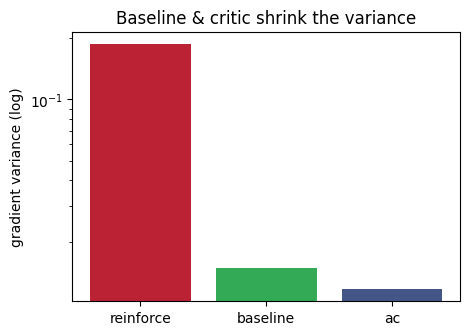

{'reinforce': 0.1864, 'baseline': 0.0149, 'ac': 0.0117}


In [13]:
# ✅ PROVIDED — measure the gradient-estimator variance on ONE fixed policy
def estimator_variance(env, pol, val, mode, N=400):
    grads = []
    for _ in range(N):
        S, A, logps, _, R = run_episode(env, pol)
        states = torch.tensor(np.array(S), dtype=torch.float32)
        G = torch.tensor(discounted_returns(R), dtype=torch.float32)
        if   mode == 'reinforce': w = G
        elif mode == 'baseline':  w = G - val(states).detach()
        else:
            with torch.no_grad():
                v = val(states); vn = torch.cat([v[1:], torch.zeros(1)])
            w = torch.tensor(R, dtype=torch.float32) + GAMMA*vn - v
        loss = -(w * torch.stack(logps)).sum()
        pol.zero_grad(); loss.backward()
        grads.append(torch.cat([p.grad.flatten() for p in pol.parameters()]).clone())
    return float(torch.stack(grads).var(0).mean())
vs = {m: estimator_variance(ArcherMDP(), pol2, val2, m) for m in ['reinforce','baseline','ac']}
plt.figure(figsize=(5,3.5)); plt.bar(vs.keys(), vs.values(), color=['#b23','#3a5','#458'])
plt.yscale('log'); plt.ylabel('gradient variance (log)'); plt.title('Baseline & critic shrink the variance'); plt.show()
print({k: round(v,4) for k,v in vs.items()})

In [14]:
# ✅ PROVIDED — does the archer walk in before shooting? (greedy rollout)
def greedy_eval(env, pol, n=300):
    tot = 0.
    for _ in range(n):
        s, _ = env.reset(); done = False
        while not done:
            with torch.no_grad():
                a = int(torch.argmax(pol(torch.tensor(s, dtype=torch.float32))))
            s, r, term, trunc, _ = env.step(a); tot += r; done = term or trunc
    return tot / n
for name, p in [('REINFORCE',pol1), ('+baseline',pol2), ('Actor-Critic',pol3)]:
    print(f'{name:14s} greedy return: {greedy_eval(ArcherMDP(), p):.2f}')

REINFORCE      greedy return: 4.91
+baseline      greedy return: 9.60
Actor-Critic   greedy return: 9.62


## Part C · Analysis, ablations & written answers

Put answers in the cell below (a few sentences each).

1. **Variance ladder.** Read off your variance bar chart. Roughly how much does the
   baseline cut the gradient variance vs vanilla REINFORCE? And the critic?
2. **Why does plain REINFORCE stall?** On this task vanilla REINFORCE often plateaus
   well below the others. Tie this to the variance you measured.
3. **Did the archer learn to walk in?** From the greedy returns, which methods learned
   *step closer → shoot* rather than shooting immediately from far away?
4. **Ablations (run + report).**
   - Set `ent_coef = 0.0` in `actor_critic`. What happens, and why?
   - Set `warmup = 0`. Does Actor-Critic still converge as reliably? Why might a
     cold critic destabilise the actor early on?
   - In `reinforce`, what happens to the bandit if you start `lr` very high (e.g. 0.2)?
5. **Stretch (optional).** Add a **continuous-aim** head: replace the 9 discrete angles
   with a Gaussian over a real angle (`mean`, `log_std` outputs; sample, score with the
   Normal log-prob). Train it with REINFORCE on the bandit. This is the thing a
   value/argmax method *cannot* do — and the §1.2 motivation for policy gradients.

**Deliverable:** this notebook with all 📝 TODOs filled, the three plots rendered,
and your Part C answers. Submit the `.ipynb` (or a Colab share link).

In [16]:
# 📝 Your Part C written answers here (as comments or a markdown cell)

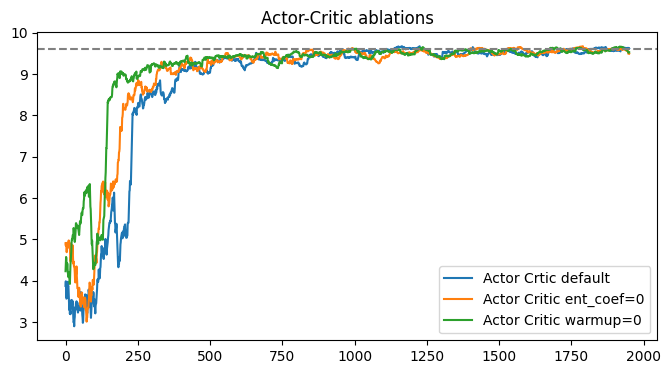

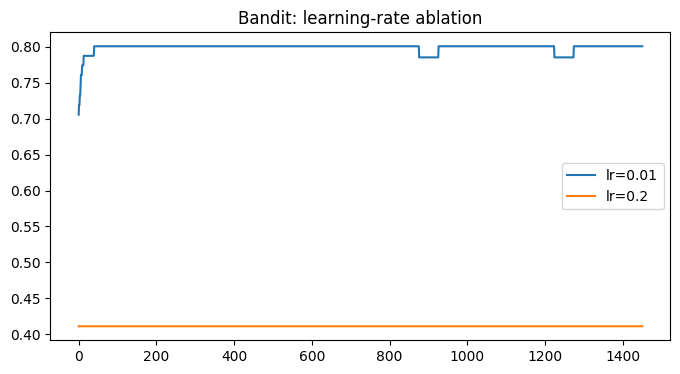

In [17]:
# Part C - ablations and run + report
_, _, c_ent0  = actor_critic(ArcherMDP(), ent_coef=0.0)
_, _, c_warm0 = actor_critic(ArcherMDP(), warmup=0)
_, hb = train_bandit(lr=0.2)

plt.figure(figsize=(8, 4))
for c, lbl in [(c3, 'Actor Crtic default'), (c_ent0, 'Actor Critic ent_coef=0'), (c_warm0, 'Actor Critic warmup=0')]:
    plt.plot(smooth(c), label=lbl)
plt.axhline(9.6, ls='--', c='gray'); plt.legend(); plt.title('Actor-Critic ablations'); plt.show()

plt.figure(figsize=(8, 4))
plt.plot(smooth(hist_b), label='lr=0.01'); plt.plot(smooth(hb), label='lr=0.2')
plt.legend(); plt.title('Bandit: learning-rate ablation'); plt.show()

1. Variance ladder: The result for the variance calculation for all there runs is {'reinforce': 0.1864, 'baseline': 0.0149, 'ac': 0.0117}. We can see from the result the baseline cuts the vanilla reinforce variance by 12.51 times. The critic cuts the vanilla reinforce variance by ~16 times. Most of these benefits in variance improvement comes from baseline subtracting state value against the random spawn distance and shoot step. The TD step then shaves further variance by reducing the noice using critic step calculation.

2. From the curves and variance bar chart we can clearly see that the REINFORCE approach stalls as it climbs slowly and return stays at 4-6 consistently with variance. The returns are mostly from taking the spawn approach to shooting rather than a plan or understanding the pattern of the highest return.

Even after 1500 episodes the REINFORCE doesn't work out a plan whereas Baseline and Critic improves and climbs to the right return strategy while reducing noise significantly around 250 episodes whereas REINFORCE keeps showing the same high vairance till 1500 episodes

3. REINFORCE doesn't learn the strategy and keep doing the same spawn and shoot approach from everywhere leading to score of 4.91 in terms of the greedy approach and fails to learn to walk in and shoot. Whereas, BASELINE and Actor-Critic approach learns the strategy of walk in and shoot, showing the returns of 9.60 and 9.62 respectively. With Actor-Critic at 9.62 being the best.

4.

